In [1]:
import pandas as pd

In [7]:

def profile_dataset(df: pd.DataFrame) -> dict:
    profile = {
        "rows": df.shape[0],
        "columns": df.shape[1],
        "column_names": list(df.columns),
        "dtypes": df.dtypes.to_dict(),
        "missing_values": df.isna().sum().to_dict(),
        "duplicates": int(df.duplicated().sum()),
        "numeric_columns": list(
            df.select_dtypes(include="number").columns
        ),
        "categorical_columns": list(
            df.select_dtypes(include="object").columns
        ),
    }

    return profile

In [35]:
def metric_dataset(df : pd.DataFrame , metric : str) -> dict:
    numerical_columns = list(df.select_dtypes(include="number").columns)
    metrics = ["mean","median","max","min","std"]

    metric = metric.rstrip().lower()

    metric_dict = {"Metric" : metric}

    for col in numerical_columns:
        if metric in metrics:
            metric_dict[col] = float(df[col].agg(metric))
        
    return metric_dict



In [36]:
df = pd.read_csv("../data/raw/ai4i2020.csv")

In [38]:
metric_dataset(df,"std")

{'Metric': 'std',
 'UDI': 2886.8956799071675,
 'Air temperature [K]': 2.0002586829157516,
 'Process temperature [K]': 1.4837342191657208,
 'Rotational speed [rpm]': 179.2840959134266,
 'Torque [Nm]': 9.968933725121337,
 'Tool wear [min]': 63.65414663663636,
 'Machine failure': 0.18098084265065362,
 'TWF': 0.06767051004531426,
 'HDF': 0.10662498247919606,
 'PWF': 0.09700871645943425,
 'OSF': 0.09851360562404211,
 'RNF': 0.043549737748530666}

In [15]:
profile_dataset(df)

/var/folders/cl/jjptsfwd2x357nx1tsybxqzc0000gn/T/ipykernel_26684/2582647713.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include="object").columns


{'rows': 10000,
 'columns': 14,
 'column_names': ['UDI',
  'Product ID',
  'Type',
  'Air temperature [K]',
  'Process temperature [K]',
  'Rotational speed [rpm]',
  'Torque [Nm]',
  'Tool wear [min]',
  'Machine failure',
  'TWF',
  'HDF',
  'PWF',
  'OSF',
  'RNF'],
 'dtypes': {'UDI': dtype('int64'),
  'Product ID': <StringDtype(na_value=nan)>,
  'Type': <StringDtype(na_value=nan)>,
  'Air temperature [K]': dtype('float64'),
  'Process temperature [K]': dtype('float64'),
  'Rotational speed [rpm]': dtype('int64'),
  'Torque [Nm]': dtype('float64'),
  'Tool wear [min]': dtype('int64'),
  'Machine failure': dtype('int64'),
  'TWF': dtype('int64'),
  'HDF': dtype('int64'),
  'PWF': dtype('int64'),
  'OSF': dtype('int64'),
  'RNF': dtype('int64')},
 'missing_values': {'UDI': 0,
  'Product ID': 0,
  'Type': 0,
  'Air temperature [K]': 0,
  'Process temperature [K]': 0,
  'Rotational speed [rpm]': 0,
  'Torque [Nm]': 0,
  'Tool wear [min]': 0,
  'Machine failure': 0,
  'TWF': 0,
  'HDF': 

In [39]:
df

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0


In [55]:
df["Air temperature [K]"]

0       298.1
1       298.2
2       298.1
3       298.2
4       298.2
        ...  
9995    298.8
9996    298.9
9997    299.0
9998    299.0
9999    299.0
Name: Air temperature [K], Length: 10000, dtype: float64

In [ ]:
import matplotlib.pyplot as plt

def categorical_viz(df : pd.DataFrame , col):

    plt.figure(figsize=(6,6))


    X_cat = df[col].unique().tolist()
    Y_cat = df[col].value_counts().tolist()

    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Count")


    plt.grid()
    plt.bar(X_cat,Y_cat)
    return plt.show()

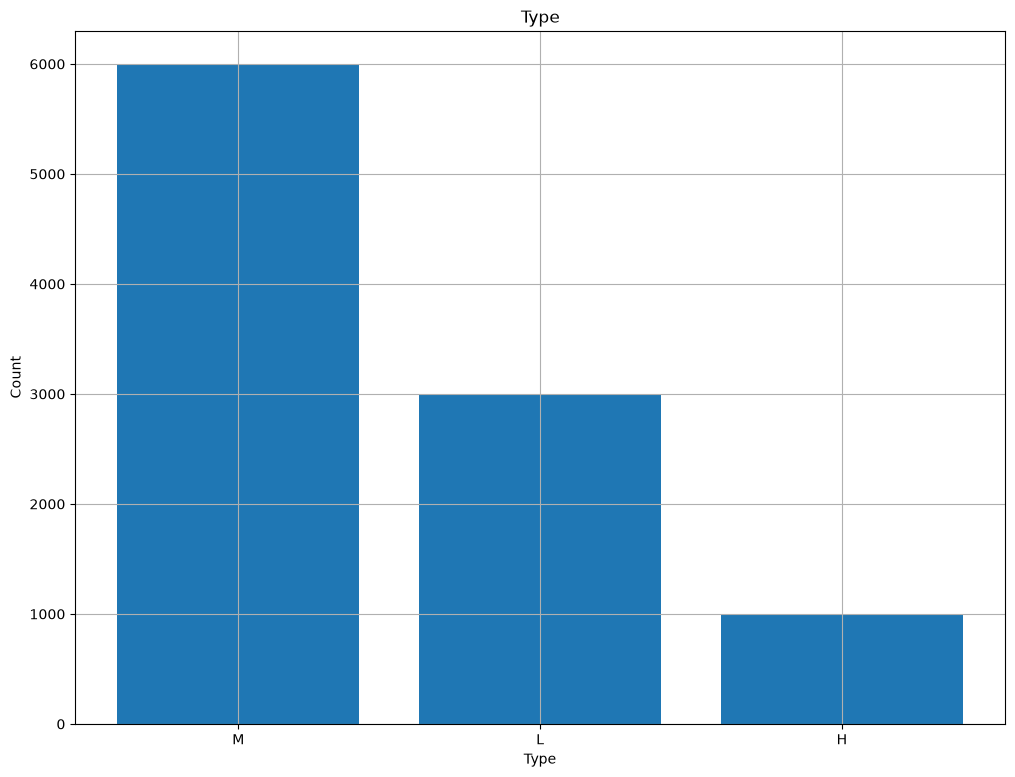

In [53]:
categorical_viz(df,"Type")

In [ ]:
def numerical_viz(df: pd.DataFrame, x_col: str, y_col: str):
    fig, ax = plt.subplots(figsize=(6,6))

    
    X_val = df[x_col]
    Y_val = df[y_col]

    ax.plot(X_val,Y_val)
    ax.set_title(f"{x_col} vs {y_col}")
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)

    
    return fig

TypeError: 'Text' object is not callable

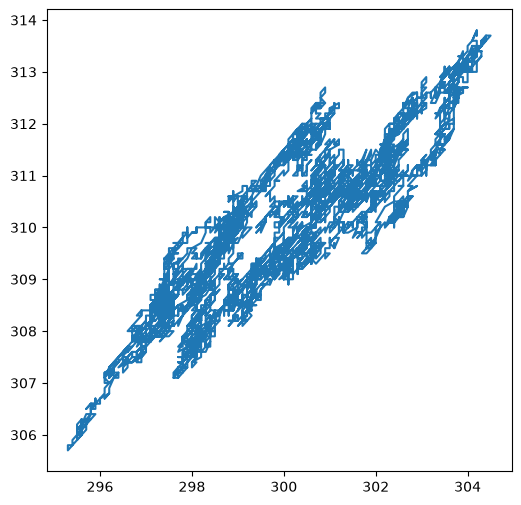

In [59]:
numerical_viz(df,"Air temperature [K]" , "Process temperature [K]")
